# 数组计算：广播


我们在[NumPy数组的计算：通用函数](02.03-Computation-on-arrays-ufuncs.ipynb)中看到，NumPy的通用函数可以用于*向量化*操作，从而消除缓慢的Python循环。

本章讨论了*广播*：一组规则，使得NumPy能够在不同大小和形状的数组之间应用二元运算（例如，加法、减法、乘法等）。

## 引入广播机制

请回忆，对于相同大小的数组，二元操作是逐元素进行的。

In [1]:
import numpy as np

In [2]:
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
a + b

array([5, 6, 7])

广播允许在不同大小的数组上执行这些类型的二元操作——例如，我们可以同样轻松地将一个标量（可以视为零维数组）添加到一个数组中：

In [3]:
a + 5

array([5, 6, 7])

我们可以将其视为一种操作，它将值 `5` 拉伸或复制到数组 `[5, 5, 5]` 中，并对结果进行求和。

我们也可以类似地将这个想法扩展到更高维的数组。请观察当我们将一维数组与二维数组相加时的结果：

In [4]:
M = np.ones((3, 3))
M

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [5]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

这里一维数组 `a` 被扩展或广播到第二个维度，以匹配 `M` 的形状。

虽然这些例子相对容易理解，但更复杂的情况可能涉及两个数组的广播。考虑以下示例：

In [6]:
a = np.arange(3)
b = np.arange(3)[:, np.newaxis]

print(a)
print(b)

[0 1 2]
[[0]
 [1]
 [2]]


In [7]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

正如之前所述，我们将一个值拉伸或广播以匹配另一个值的形状，而在这里，我们同时拉伸了 *a* 和 *b* 以匹配一个共同的形状，结果是一个二维数组！

这些示例的几何图形在下图中可视化。（生成此图的代码可以在在线[附录](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/06.00-Figure-Code.ipynb#Broadcasting)中找到，并且经过改编自[astroML](http://astroml.org)文档中的来源。已获得许可。）

![Broadcasting Visual](figures/02.05-broadcasting.png)

光框代表广播的值。这种思考广播的方式可能会引发关于其内存使用效率的问题，但请放心：NumPy 的广播实际上并不会在内存中复制广播的值。不过，在我们思考广播时，这仍然可以作为一个有用的心理模型。

## 广播规则

NumPy中的广播遵循一套严格的规则，以确定两个数组之间的交互：

- 规则1：如果两个数组在维度数量上不同，则较少维度的数组形状在其前面（左侧）用1进行*填充*。

- 规则2：如果两个数组在任何一个维度上的形状不匹配，则该维度形状为1的数组会被拉伸以匹配另一个形状。

- 规则3：如果在任何一个维度上大小不一致且两者都不等于1，则会引发错误。

为了使这些规则更加清晰，我们将详细考虑几个示例。

### 广播示例 1

假设我们想将一个二维数组加到一个一维数组上：

In [8]:
M = np.ones((2, 3))
a = np.arange(3)

让我们考虑对这两个数组进行操作，它们的形状如下：

- `M.shape` 为 `(2, 3)`

- `a.shape` 为 `(3,)`

根据规则1，我们看到数组 `a` 的维度较少，因此我们在左侧用1填充它：

- `M.shape` 保持为 `(2, 3)`

- `a.shape` 变为 `(1, 3)`

根据规则2，我们现在看到第一个维度不一致，因此我们将该维度扩展以匹配：

- `M.shape` 保持为 `(2, 3)`

- `a.shape` 变为 `(2, 3)`

现在形状一致，我们可以得出最终形状将是 `(2, 3)`。

In [9]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.]])

### 广播示例 2

现在我们来看看一个需要对两个数组进行广播的示例：

In [10]:
a = np.arange(3).reshape((3, 1))
b = np.arange(3)

我们将再次开始确定数组的形状：

- `a.shape` 为 `(3, 1)`

- `b.shape` 为 `(3,)`

规则1规定我们必须用一填充 `b` 的形状：

- `a.shape` 保持为 `(3, 1)`

- `b.shape` 变为 `(1, 3)`

规则2告诉我们，必须将每个 ``1`` 升级以匹配另一个数组的相应大小：

- `a.shape` 变为 `(3, 3)`

- `b.shape` 变为 `(3, 3)`

由于结果匹配，这些形状是兼容的。我们可以在这里看到：

In [11]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

### 广播示例 3

接下来，我们来看一个两个数组不兼容的示例：

In [12]:
M = np.ones((3, 2))
a = np.arange(3)

这只是与第一个例子稍有不同的情况：矩阵 `M` 被转置了。

这对计算有什么影响？数组的形状如下：

- `M.shape` 为 `(3, 2)`

- `a.shape` 为 `(3,)`

再次根据规则1，我们必须用一填充 `a` 的形状：

- `M.shape` 保持为 `(3, 2)`

- `a.shape` 变为 `(1, 3)`

根据规则2，`a` 的第一维被拉伸以匹配 `M` 的第一维：

- `M.shape` 保持为 `(3, 2)`

- `a.shape` 变为 `(3, 3)`

现在我们遇到规则3——最终的形状不匹配，因此这两个数组是不兼容的，这一点可以通过尝试进行此操作来观察。

In [13]:
M + a

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

注意这里可能存在的混淆：你可以想象通过在右侧而不是左侧用1填充`a`的形状来使`a`和`M`兼容。

但这并不是广播规则的工作方式！

这种灵活性在某些情况下可能是有用的，但也会导致潜在的歧义。

如果你希望进行右侧填充，可以通过显式地重新调整数组形状来实现（我们将在此使用[NumPy数组基础](02.02-The-Basics-Of-NumPy-Arrays.ipynb)中介绍的 `np.newaxis` 关键字）：

In [14]:
a[:, np.newaxis].shape

(3, 1)

In [15]:
M + a[:, np.newaxis]

array([[1., 1.],
       [2., 2.],
       [3., 3.]])

请注意，虽然我们在这里专注于 `+` 运算符，但这些广播规则适用于 *任何* 二元通用函数（ufunc）。

例如，这里是 `logaddexp(a, b)` 函数，它以比简单方法更高的精度计算 `log(exp(a) + exp(b))`。

In [16]:
np.logaddexp(M, a[:, np.newaxis])

array([[1.31326169, 1.31326169],
       [1.69314718, 1.69314718],
       [2.31326169, 2.31326169]])

有关可用的多种通用函数的更多信息，请参阅 [NumPy 数组上的计算：通用函数](02.03-Computation-on-arrays-ufuncs.ipynb)。

## 实践中的广播：


广播操作是本书中许多示例的核心。

接下来，我们将查看一些它们可能有用的实例。

### 对数组进行中心化处理：

在[NumPy数组计算：通用函数](02.03-Computation-on-arrays-ufuncs.ipynb)中，我们看到ufuncs使得NumPy用户无需显式编写缓慢的Python循环。广播功能进一步扩展了这一能力。

数据科学中一个常见的例子是从数据数组中减去行均值(中心化)。

假设我们有一个包含10个观测值的数组，每个观测值由3个数值组成。

按照标准惯例（参见[Scikit-Learn中的数据表示](05.02-Introducing-Scikit-Learn.ipynb#Data-Representation-in-Scikit-Learn)），我们将其存储为一个$10 \times 3$的数组。

In [17]:
rng = np.random.default_rng(seed=1701)
X = rng.random((10, 3))

我们可以通过在第一维度上使用 `mean` 聚合来计算每一列的均值。

In [18]:
Xmean = X.mean(0)
Xmean

array([0.38503638, 0.36991443, 0.63896043])

现在我们可以通过减去均值来对 `X` 数组进行中心化（这是一种广播操作）：

In [19]:
X_centered = X - Xmean

为了确保我们正确地完成了这一过程，我们可以检查中心化数组的均值是否接近零：

In [20]:
X_centered.mean(0)

array([ 4.99600361e-17, -4.44089210e-17,  0.00000000e+00])

在机器精度范围内，均值现在为零。

### 绘制二维函数

广播的一个常见应用是基于二维函数显示图像。

如果我们想定义一个函数 $z = f(x, y)$，可以使用广播在网格上计算该函数。

In [21]:
# x and y have 50 steps from 0 to 5
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 50)[:, np.newaxis]

z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

我们将使用Matplotlib绘制这个二维数组，如下图所示（这些工具将在[密度和轮廓图](04.04-Density-and-Contour-Plots.ipynb)中详细讨论）。

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

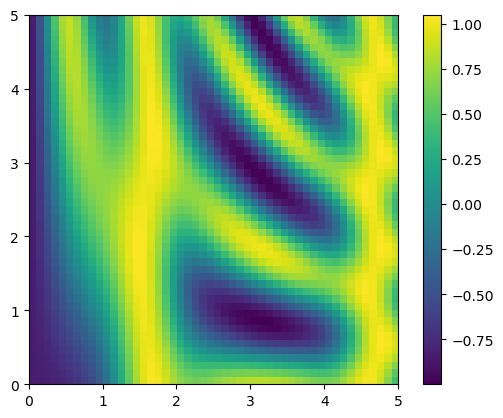

In [23]:
plt.imshow(z, origin='lower', extent=[0, 5, 0, 5])
plt.colorbar();

结果是对二维函数的引人注目的可视化。